In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

## Examples Cells

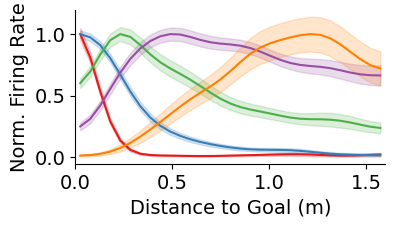

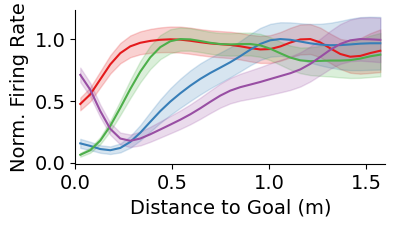

In [51]:
# plot some individual units
from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg
from GridMaze.analysis.core import get_clusters as gc
import numpy as np
from cmap import Colormap

reload(dtg)
reload(gc)

example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m7.2022-07-02.maze_cluster55",
    "m7.2022-07-25.maze_cluster73",
]

other_example_clusters = [
    "m7.2022-07-10.maze_cluster8",
    "m2.2022-07-13.maze_cluster19",
    "m2.2022-07-13.maze_cluster86",
    "m7.2022-07-10.maze_cluster53",
]


def plot_example_neurons(clusters, ax, cmap="hls"):
    cm = Colormap(cmap)
    colors = cm(np.linspace(0, 1, len(clusters)))
    for cluster, c in zip(clusters, colors):
        Cluster = gc.get_cluster(cluster)
        Cluster.plot_tuning(feature="distance_to_goal", feature_kwargs={"normalisation": "max", "color": c}, ax=ax)
    ax.set_xlabel("Distance to Goal (m)")
    ax.set_ylabel("Norm. Firing Rate")
    return


f1, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(example_clusters, ax, cmap="colorbrewer:set1_5")
f1.savefig("../results/distance_to_goal/figures/main/example_neurons_1.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(other_example_clusters, ax, cmap="colorbrewer:set1_4")
f2.savefig("../results/distance_to_goal/figures/main/example_neurons_2.pdf")

## Population Tuning

In [9]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

In [10]:
# get data to plot distance tuning heatmaps
population_tuning_df = pt.get_population_tuning_df(late_sessions=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


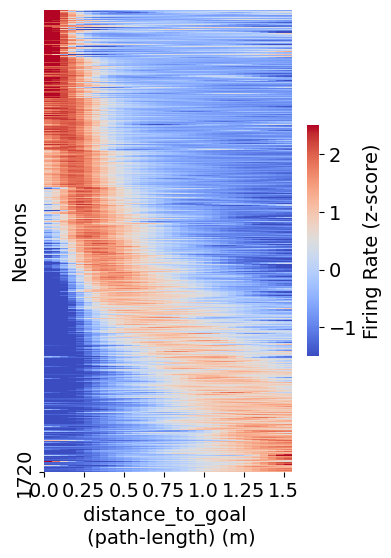

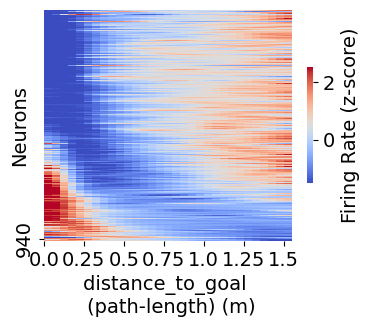

In [26]:
f1, ax = plt.subplots(1, 1, figsize=(4, 6))
reload(pt)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
f1.savefig("../results/distance_to_goal/figures/main/heatmap_1.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 3))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
f2.savefig("../results/distance_to_goal/figures/main/heatmap_2.pdf")

## What distance metric best fits the data?

In [40]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

cpd_summary_df = dm.get_distance_metric_CPD_summary_df(subfolder="progress_mon_decr_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.850, p-value: 4.673e-03


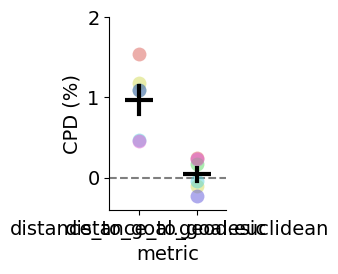

In [53]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    maze_names=["maze_1", "maze_2"],
    late_sessions=True,
    ax=ax,
)
ax.set_ylim(-0.4, 2.0)
f.savefig("../results/distance_to_goal/figures/main/cpd_comparison.pdf")

## Tunning curves are best fit to a family of gamma distributions (not gaussian)

In [39]:
fit_summary_df = pt.get_tuning_fits_summary_df(late_sessions=False)

clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


gamma_4p vs gaussian_4p: 
 t-stat: 7.322, p-value: 7.447e-04


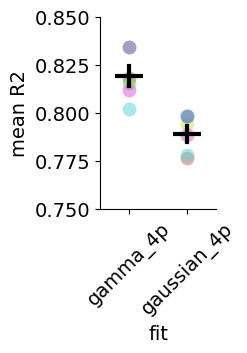

In [50]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
pt.plot_cross_subject_curve_fit_comparison(fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], ax=ax)
ax.set_ylim(0.75, 0.85)
f.savefig("../results/distance_to_goal/figures/main/gamma_vs_gaussian.pdf")

## Unit Match

In [4]:
import numpy as np
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.unit_match import get_across_maze_matches as mm
from GridMaze.analysis.unit_match import distance_to_goal as um_dtg

In [4]:
# get matches like this
matched_clusters = mm.get_cross_maze_matches(
    subject_ID="m2",
    maze_pair=("maze_1", "maze_2"),
    single_units=True,
    tuning_metric="distance_to_goal",
    min_split_half_corr=0.3,  # only keep matches that a both distance tuned to start with
    return_as="cluster_objects",
    verbose=True,
)

Found 260 matches for m2, maze_1.maze_2, with the given criteria.


In [5]:
# I've selected a few matched clusters from the above list that we can have a look at ...
_matched_clusters = np.array(
    [
        ["m2.2022-07-05.maze_cluster64", "m2.2022-07-11.maze_cluster49"],  # Maze_1, Maze_2
        ["m2.2022-07-03.maze_cluster90", "m2.2022-07-11.maze_cluster94"],
        ["m2.2022-07-05.maze_cluster28", "m2.2022-07-11.maze_cluster26"],
        ["m2.2022-07-04.maze_cluster86", "m2.2022-07-12.maze_cluster84"],
        ["m2.2022-07-05.maze_cluster44", "m2.2022-07-13.maze_cluster65"],
        ["m2.2022-07-02.maze_cluster87", "m2.2022-07-09.maze_cluster91"],
    ]
)

matched_clusters = np.array([[gc.get_cluster(C) for C in pair] for pair in _matched_clusters])

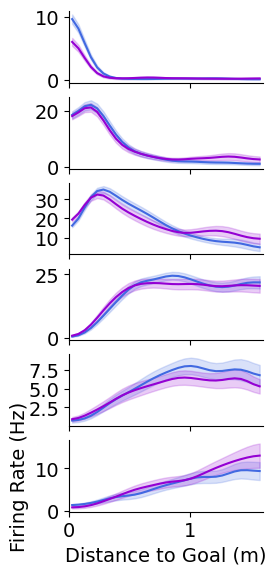

In [ ]:
# set up fig for plotting matched clusters
f, axes = plt.subplots(6, 1, figsize=(2.5, 6.5), sharex=True)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

# plot matched cluster tuning curves on the same axis :)
for ax, pair in zip(axes, matched_clusters):
    for Clust, color in zip(pair, ["royalblue", "darkviolet"]):
        Clust.plot_tuning(
            feature="distance_to_goal",
            ax=ax,
            feature_kwargs={"color": color},
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")
f.savefig("../results/distance_to_goal/figures/main/example_matched_clusters.pdf")

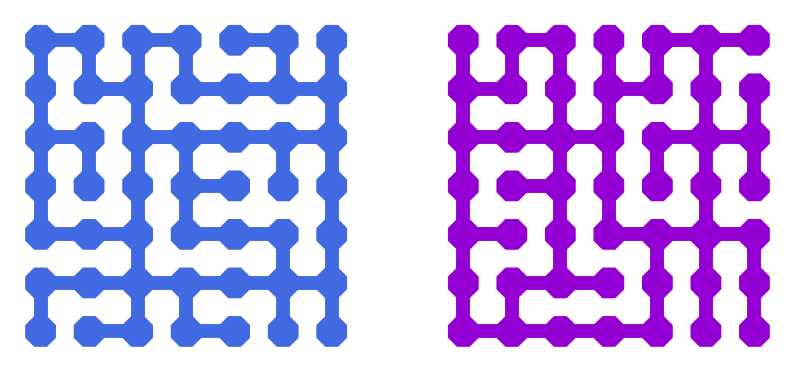

In [68]:
# plot coloured maze silhouttes to make plot legend
from GridMaze.maze import representations as mr
from GridMaze.maze import plotting as mp

f, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, maze_name, color in zip(axes, ["maze_1", "maze_2"], ["royalblue", "darkviolet"]):
    simple_maze = mr.get_simple_maze(maze_name)
    mp.plot_simple_maze_silhouette(simple_maze, ax, color)
f.savefig("../results/distance_to_goal/figures/main/maze_silhouettes_legend.pdf")

## Decoding distance to goal

In [69]:
# get distance to goal decoding results
# what can we read out from these tuning curves? how good is the distance decoding at longer distances
from GridMaze.analysis.distance_to_goal import logreg_decoder as ld

results_df = ld.load_decoding_results(subfolder="all_dist")

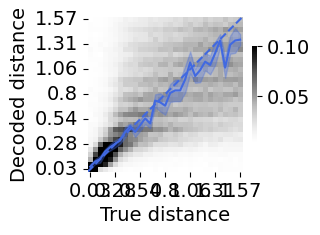

In [72]:
reload(ld)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ld.plot_distance_decoding_probs(results_df, moving_only=True, ax=ax)
f.savefig("../results/distance_to_goal/figures/main/distance_decoding.pdf")

## Could this distance to goal code be theta-modulated?

In [91]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.lfp import traces as lt
from GridMaze.analysis.lfp import theta_mod as tm
from GridMaze.analysis.distance_to_goal import theta_mod_decoder as tmd

In [89]:
# example session for looking at LFP
session = gs.get_maze_sessions(
    subject_IDs=["m3"],
    maze_names=["maze_1"],
    days_on_maze=[12],
    with_data=["lfp_signal", "lfp_times", "lfp_metrics", "cluster_metrics"],
    must_have_data=True,
)

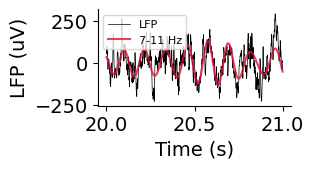

In [120]:
reload(lt)
f1, ax = plt.subplots(1, 1, figsize=(2.5, 1.25))
lt.plot_lfp_with_osc(session, window=(20, 21), freq_range=(7, 11), N=4, ax=ax)
f1.savefig("../results/distance_to_goal/figures/main/lfp_example.pdf")

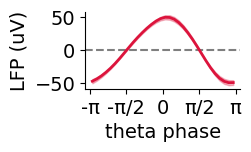

In [92]:
# similar to previous work we see the mFC cells are modulated by theta phase
reload(tm)
theta_aligned_signal = tm.get_theta_aligned_lfp_df()
f2, ax = plt.subplots(1, 1, figsize=(2, 1))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=ax)
f2.savefig("../results/distance_to_goal/figures/main/theta_aligned_lfp.pdf")

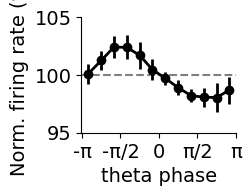

In [127]:
reload(tm)
population_theta_df = tm.get_population_theta_mod()
f3, ax = plt.subplots(1, 1, figsize=(2, 1.5))
tm.plot_population_theta_mod(population_theta_df, ax=ax)
f3.savefig("../results/distance_to_goal/figures/main/population_theta_mod.pdf")

In [ ]:
theta_mod_decoding = tmd.load_decoding_results(lfp_type="theta_mid")

                  T2         F  df1  df2      pval
hotelling  16.323042  7.345369    2    9  0.012838


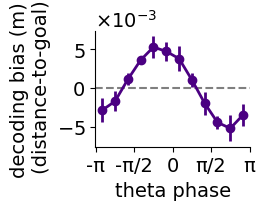

In [128]:
reload(tmd)
f4, ax = plt.subplots(1, 1, figsize=(2, 1.5))
tmd.plot_decoding_theta_bias(theta_mod_decoding, ax=ax, print_stats=True)
f4.savefig("../results/distance_to_goal/figures/main/theta_mod_distance_decoding.pdf")

# Supplementary Materials

In [41]:
# we can also look at the difference between weights (L1_ratio) between distance metrics in the regression
# with optimised regularisation
L1_ratio_summary_df = dm.get_L1_ratio_summary_df("all_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: L1_ratio t-stat: 3.845, p-value: 0.012


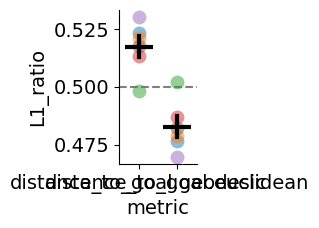

In [75]:
f, ax = plt.subplots(1, 1, figsize=(1, 2))
dm.plot_cross_subject_weight_comparison(
    L1_ratio_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    norm_metric="L1_ratio",
    late_sessions=True,
    maze_names=["maze_1", "maze_2"],
    ax=ax,
    print_stats=True,
)
f.savefig("../results/distance_to_goal/figures/supp/L1_ratio_comparison.pdf")

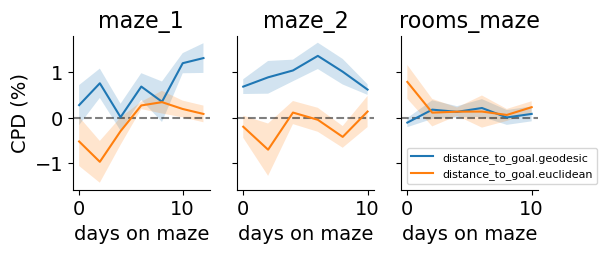

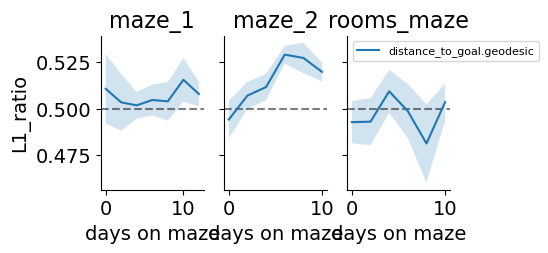

In [76]:
# we can visualise the CPD and L1_ratio comparisons across learning and across mazes
reload(dm)
f1, axes = plt.subplots(1, 3, figsize=(6, 2), sharey=True)
dm.plot_CPD_timeseries(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    axes=axes,
    group_days=2,
)
f1.savefig("../results/distance_to_goal/figures/supp/cpd_timeseries.pdf")

f2, axes = plt.subplots(1, 3, figsize=(4.5, 2), sharey=True)
dm.plot_weights_comparison_timeseries(
    L1_ratio_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    plot_metric="distance_to_goal.geodesic",
    group_days=2,
    axes=axes,
)
f2.savefig("../results/distance_to_goal/figures/supp/L1_ratio_timeseries.pdf")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.850, p-value: 0.005
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: 
 t-stat: 4.034, p-value: 0.010
distance_to_goal.geodesic_vs_distance_to_goal.future: 
 t-stat: 3.597, p-value: 0.016
distance_to_goal.geodesic_vs_progress_to_goal.path_length: 
 t-stat: -1.870, p-value: 0.120
distance_to_goal.geodesic_vs_progress_to_goal.time: 
 t-stat: 2.649, p-value: 0.045
distance_to_goal.euclidean_vs_distance_to_goal.manhattan: 
 t-stat: 0.521, p-value: 0.625
distance_to_goal.euclidean_vs_distance_to_goal.future: 
 t-stat: -4.605, p-value: 0.006
distance_to_goal.euclidean_vs_progress_to_goal.path_length: 
 t-stat: -3.905, p-value: 0.011
distance_to_goal.euclidean_vs_progress_to_goal.time: 
 t-stat: -0.192, p-value: 0.856
distance_to_goal.manhattan_vs_distance_to_goal.future: 
 t-stat: -3.532, p-value: 0.017
distance_to_goal.manhattan_vs_progress_to_goal.path_length: 
 t-stat: -3.322, p-value: 0.021
distance_to_goal.manha

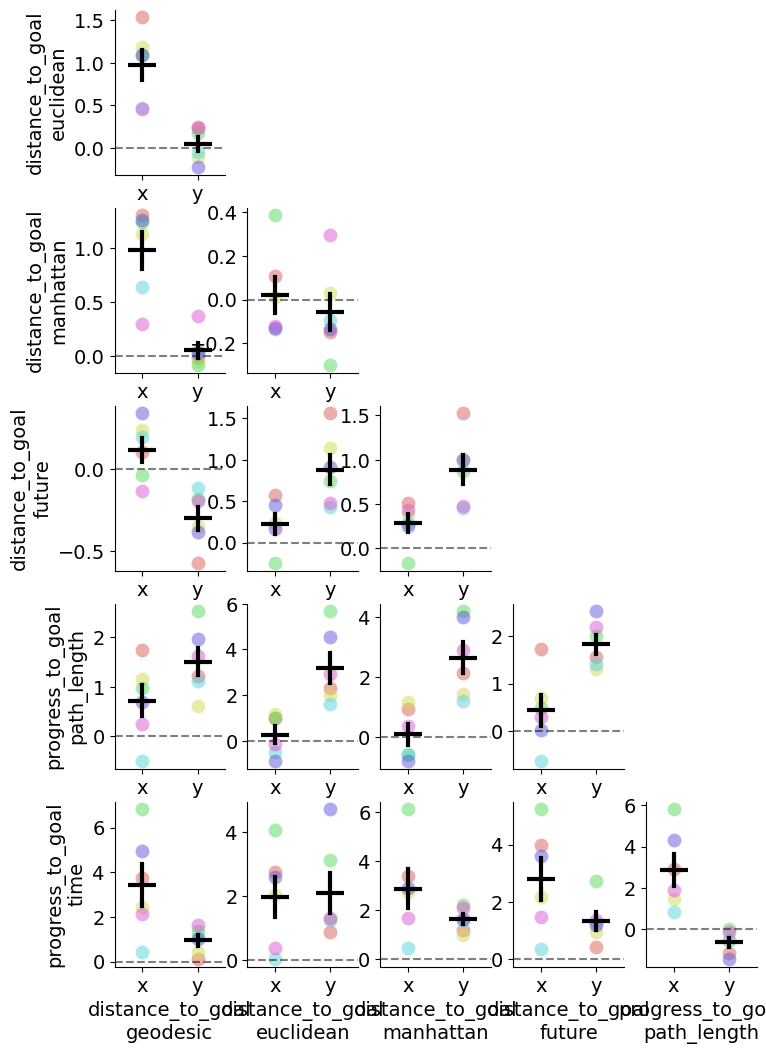

In [ ]:
# more thorough comparison of different distance & progress to goal metrics for those interested
reload(dm)
f, axes = plt.subplots(6, 6, figsize=(10, 15))
dm.plot_pairwise_CPD_cross_subject_comparisons(cpd_summary_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/pairwise_CPD_comparisons.pdf")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: L1_ratio t-stat: 3.845, p-value: 0.012
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: L1_ratio t-stat: 4.974, p-value: 0.004
distance_to_goal.geodesic_vs_distance_to_goal.future: L1_ratio t-stat: 6.775, p-value: 0.001
distance_to_goal.geodesic_vs_progress_to_goal.path_length: L1_ratio t-stat: 7.145, p-value: 0.001
distance_to_goal.geodesic_vs_progress_to_goal.time: L1_ratio t-stat: 11.637, p-value: 0.000
distance_to_goal.euclidean_vs_distance_to_goal.manhattan: L1_ratio t-stat: -0.849, p-value: 0.435
distance_to_goal.euclidean_vs_distance_to_goal.future: L1_ratio t-stat: 2.590, p-value: 0.049
distance_to_goal.euclidean_vs_progress_to_goal.path_length: L1_ratio t-stat: 5.574, p-value: 0.003
distance_to_goal.euclidean_vs_progress_to_goal.time: L1_ratio t-stat: 10.348, p-value: 0.000
distance_to_goal.manhattan_vs_distance_to_goal.future: L1_ratio t-stat: 3.319, p-value: 0.021
distance_to_goal.manhattan_vs_progress_to_goal.

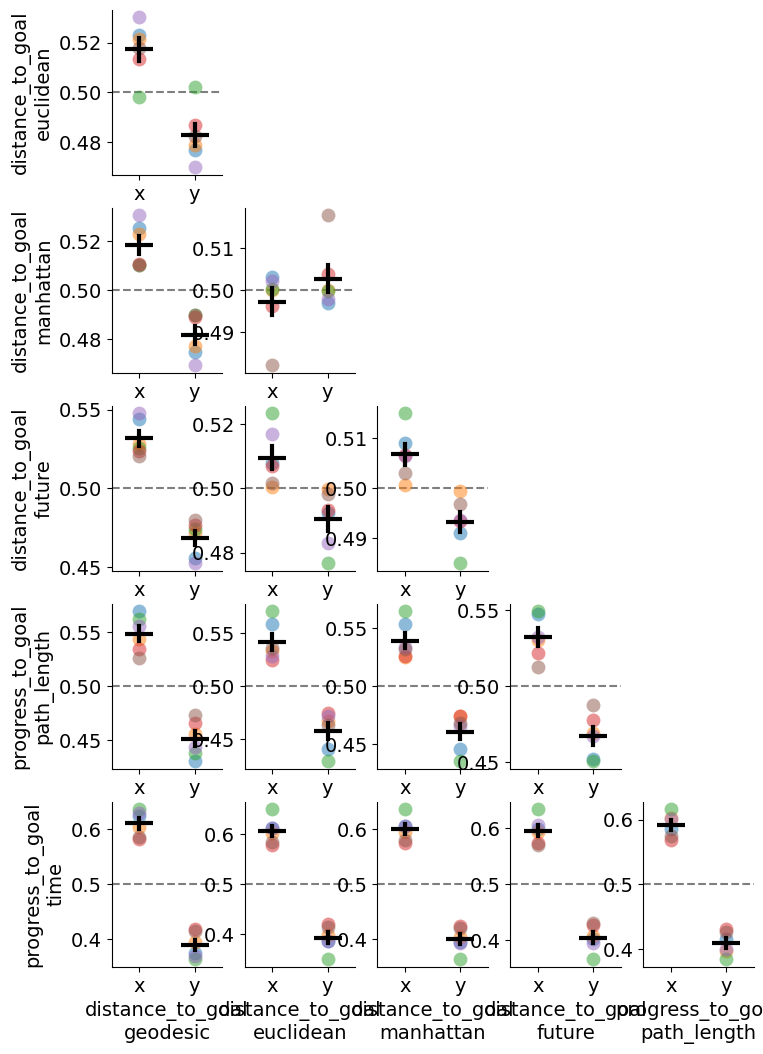

In [ ]:
# we can also compare distance metrics in a different way, L1_ratio between metrics in the regression
reload(dm)
f, axes = plt.subplots(6, 6, figsize=(10, 15))
dm.plot_all_cross_subject_weight_comparisons(L1_ratio_summary_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/pairwise_L1_ratio_comparisons.pdf")

## Visualise quantiles of the distance to goal tuning heatmap

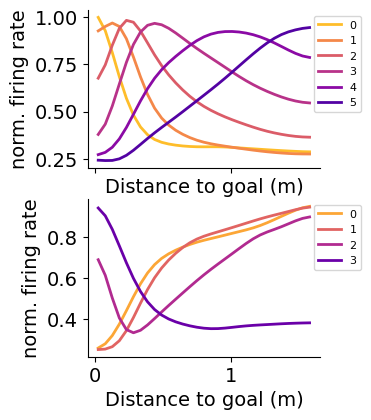

In [86]:
reload(pt)
f, axes = plt.subplots(2, 1, figsize=(3, 4.5), sharex=True)
pt.plot_population_quantiles(population_tuning_df, sign="pos", normalisation_method="max", n_quantiles=6, ax=axes[0])
pt.plot_population_quantiles(population_tuning_df, sign="neg", normalisation_method="max", n_quantiles=4, ax=axes[1])
f.savefig("../results/distance_to_goal/figures/supp/distance_tuning_quantiles.pdf")

## More on tuning across mazes

In [6]:
from GridMaze.analysis.core import unit_matching as um

Running unitmatch
Using cluster_group.tsv
Using cluster_group.tsv


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: invalid value encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: divide by zero encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])


Session pair 1/2 has [ 6  4 11  6  4] matches per shank, which is below threshold to do per shank drift correction
Calculating the probability distributions of the metric scores
Calculating the match probabilities
The percentage of units matched to themselves is: 78.62068965517241%
The percentage of false -ve's then is: 21.379310344827587% 

The rate of miss-match(es) per expected match 0.1103448275862069
The percentage of false +ve's is 0.1740506329113924% for session 1
The percentage of false +ve's is 0.1201923076923077% for session 2

This assumes that the spike sorter has made no mistakes
Number of Liberal Matches: 30
Number of Intermediate Matches: 24
Number of Conservative Matches: 24
Running unitmatch
Using cluster_group.tsv
Using cluster_group.tsv


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: invalid value encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: divide by zero encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])


Session pair 1/2 has [4 6 7 3 1] matches per shank, which is below threshold to do per shank drift correction
Calculating the probability distributions of the metric scores
Calculating the match probabilities
The percentage of units matched to themselves is: 77.85714285714286%
The percentage of false -ve's then is: 22.14285714285714% 

The rate of miss-match(es) per expected match 0.06428571428571428
The percentage of false +ve's is 0.07207207207207207% for session 1
The percentage of false +ve's is 0.1201923076923077% for session 2

This assumes that the spike sorter has made no mistakes
Number of Liberal Matches: 15
Number of Intermediate Matches: 13
Number of Conservative Matches: 13
Running unitmatch
Using cluster_group.tsv
Using cluster_group.tsv


...

Session pair 1/2 has [4 5 7 4 3] matches per shank, which is below threshold to do per shank drift correction
Calculating the probability distributions of the metric scores
Calculating the match probabilities
The percentage of units matched to themselves is: 81.81818181818183%
The percentage of false -ve's then is: 18.181818181818173% 

The rate of miss-match(es) per expected match 0.06493506493506493
The percentage of false +ve's is 0.06839945280437756% for session 1
The percentage of false +ve's is 0.10974539069359088% for session 2

This assumes that the spike sorter has made no mistakes
Number of Liberal Matches: 18
Number of Intermediate Matches: 18
Number of Conservative Matches: 18
Running unitmatch
Using cluster_group.tsv
Using cluster_group.tsv


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: invalid value encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: divide by zero encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])


Session pair 1/2 has [1 5 7 5 4] matches per shank, which is below threshold to do per shank drift correction
Calculating the probability distributions of the metric scores
Calculating the match probabilities
The percentage of units matched to themselves is: 80.79470198675497%
The percentage of false -ve's then is: 19.205298013245027% 

The rate of miss-match(es) per expected match 0.10596026490066225
The percentage of false +ve's is 0.15822784810126583% for session 1
The percentage of false +ve's is 0.12072434607645875% for session 2

This assumes that the spike sorter has made no mistakes
Number of Liberal Matches: 27
Number of Intermediate Matches: 23
Number of Conservative Matches: 23
Running unitmatch
Using cluster_group.tsv
Using cluster_group.tsv


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: invalid value encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/UnitMatchPy/metric_functions.py:326: RuntimeWarning: divide by zero encountered in divide
  ang = np.abs( x1[dim_id1,:,:,:,:] - x2[dim_id1,:,:,:,:]) / np.abs(x1[dim_id2,:,:,:,:] - x2[dim_id2,:,:,:,:])


Session pair 1/2 has [4 6 6 6 4] matches per shank, which is below threshold to do per shank drift correction
Calculating the probability distributions of the metric scores
Calculating the match probabilities
The percentage of units matched to themselves is: 85.0%
The percentage of false -ve's then is: 15.0% 

The rate of miss-match(es) per expected match 0.03571428571428571
The percentage of false +ve's is 0.05126452494873548% for session 1
The percentage of false +ve's is 0.051203277009728626% for session 2

This assumes that the spike sorter has made no mistakes
Number of Liberal Matches: 17
Number of Intermediate Matches: 16
Number of Conservative Matches: 16


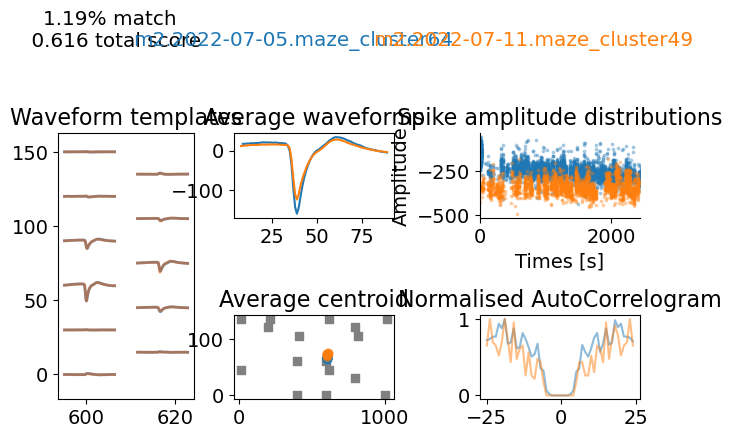

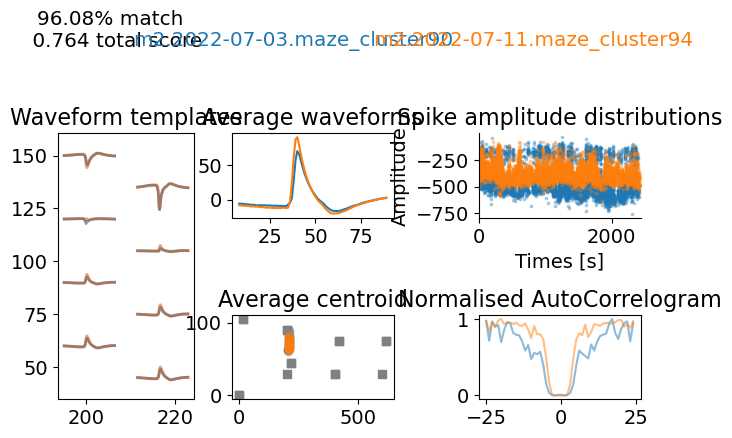

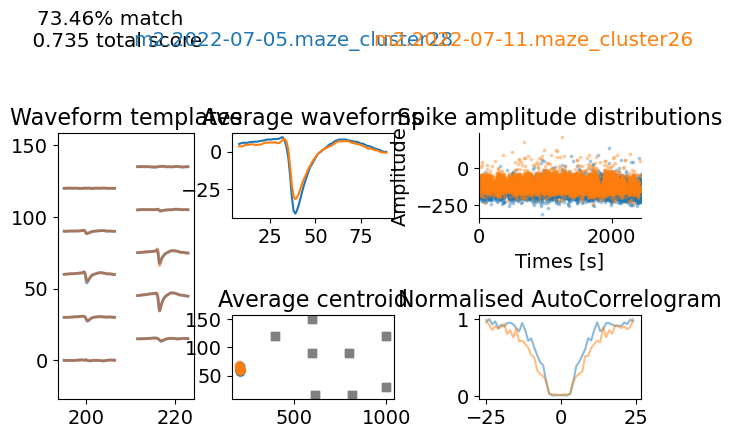

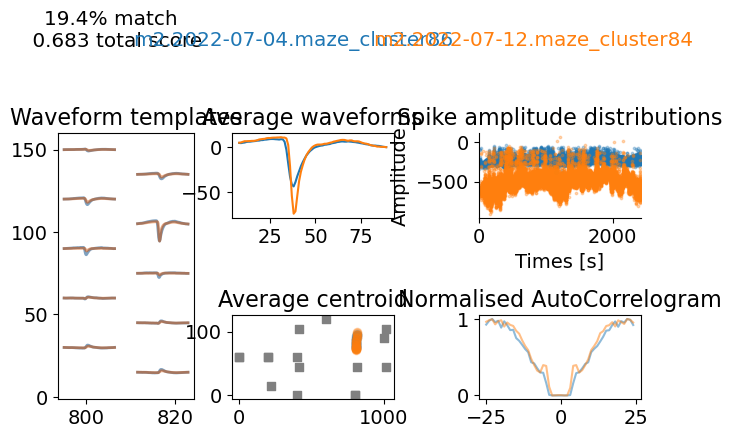

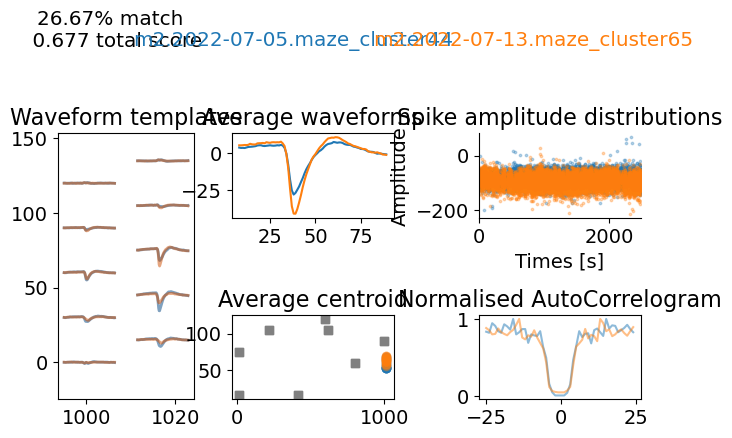

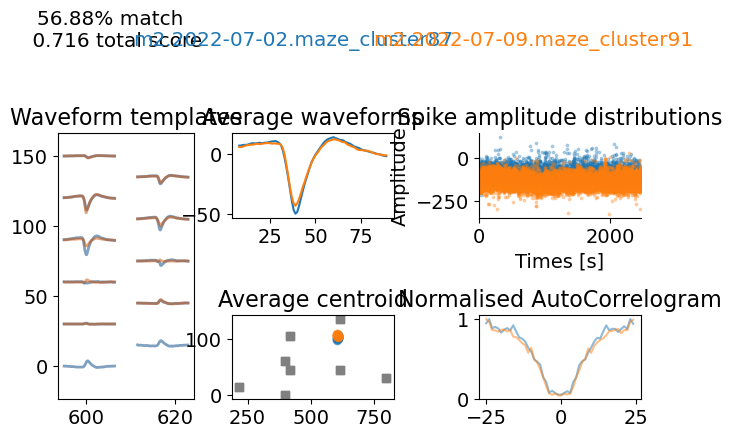

In [8]:
# lets convience ourselves that we are getting some good matched with UnitMatch
reload(um)
for i, pair in enumerate(matched_clusters):
    save_path = f"../results/distance_to_goal/figures/supp/um_reports/{pair[0].cluster_unique_ID}X{pair[1].cluster_unique_ID}.pdf"
    um.get_pairwise_report(pair[0], pair[1], save=True, save_path=save_path)

In [24]:
reload(um_dtg)
matched_tuning_dfs = um_dtg.get_matched_distance_tuning_dfs(verbose=False)

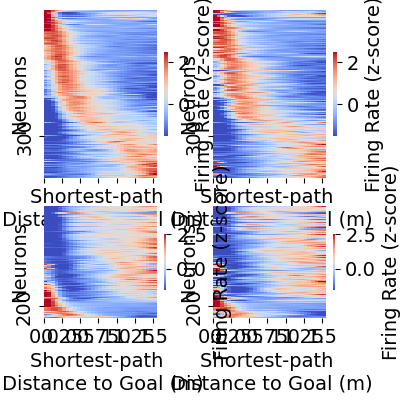

In [78]:
f, axes = plt.subplots(2, 2, figsize=(4, 4), height_ratios=[1.5, 1], sharex=True)
um_dtg.plot_matched_distance_tuning_heatmaps(*matched_tuning_dfs, min_corr=0.15, v_range=(-1.5, 2.5), axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/matched_distance_tuning_heatmaps.pdf")

Subject p-values:
   p_value
m2     0.0
m3     0.0
m4     0.0
m6     0.0
m7     0.0
m8     0.0
Random effects t-statistic: 6.549, p-value: 0.001
Subject p-values:
   p_value
m2     0.0
m3     0.0
m4   0.393
m6     0.0
m7     0.0
m8   0.021
Random effects t-statistic: 4.740, p-value: 0.005


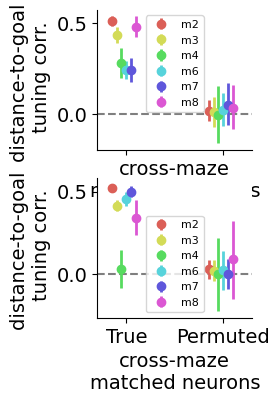

In [79]:
f, axes = plt.subplots(2, 1, figsize=(2, 4), sharex=True)
maze_pairs = [("maze_1", "maze_2"), ("maze_2", "rooms_maze")]
for maze_pair, ax in zip(maze_pairs, axes):
    results = um_dtg.get_cross_maze_corr_summary(maze_pair, verbose=False)
    um_dtg.plot_cross_maze_corrs_summary(results, print_stats=True, ax=ax)
# note m4 maze_2-rooms_maze has ~8 matched clusters so will exclude for final plot
f.savefig("../results/distance_to_goal/figures/supp/cross_maze_match_corrs.pdf")

## Another way of testing for theta modulation in distance to goal signal: tuning curves

In [47]:
# lets look at theta modulation in another way: tuning curves
from GridMaze.analysis.distance_to_goal import theta_mod_tuning as tmt

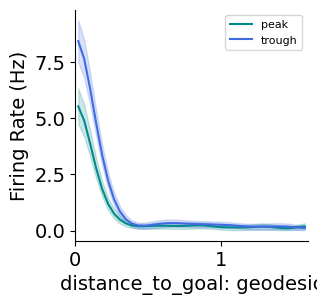

In [111]:
from GridMaze.analysis.core import get_clusters as gc

reload(gc)
Cluster = gc.get_cluster("m2.2022-07-04.maze_cluster34")
f, ax = plt.subplots(1, 1, figsize=(3, 3))
Cluster.plot_tuning(feature="distance_to_goal_theta", ax=ax)
f.savefig("../results/distance_to_goal/figures/supp/example_theta_mod_tuning.pdf")

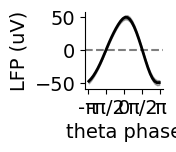

In [100]:
f1, ax = plt.subplots(1, 1, figsize=(1, 1))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=ax, color="black")
f1.savefig("../results/distance_to_goal/figures/supp/theta_aligned_for_key.pdf")

In [49]:
# load all distance tuning curves split by theta phase (peak and trough)
tuning_curves, tuning_metrics = tmt.get_population_theta_split_distance_tuning(verbose=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.thetaSpikeCounts.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.thetaSpikeCounts.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


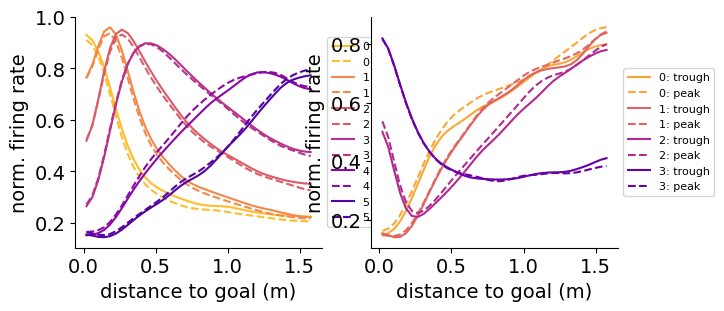

In [110]:
f, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, sign, neuron_groups in zip(axes, ["pos", "neg"], [6, 4]):
    tmt.plot_heatmap_slices(
        tuning_curves,
        tuning_metrics,
        sign=sign,
        neuron_groups=neuron_groups,
        distance_groups=False,
        how="horizontal",
        cmap="plasma_r",
        ax=ax,
    )
f.savefig("../results/distance_to_goal/figures/supp/theta_mod_tuning_curves.pdf")

t-test: t = -4.778, p = 0.002


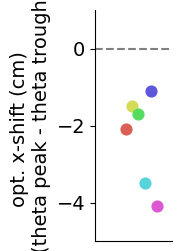

In [ ]:
# random effects statistical test, how much to we need to shift peak and trough
# tuning curves to get them to align?
reload(tmt)
f, ax = plt.subplots(1, 1, figsize=(1, 3))
tmt.plot_subject_theta_x_shifts(ax=ax, print_stats=True)
f.savefig("../results/distance_to_goal/figures/supp/theta_mod_tuning_stats.pdf")

In [59]:
# no clear anatomical organisation of distance tunned neurons across the medial wall
from GridMaze.analysis.anatomy import distance_to_goal as anat_dtg

In [60]:
anat_df = anat_dtg.get_population_anatomy_df()

clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


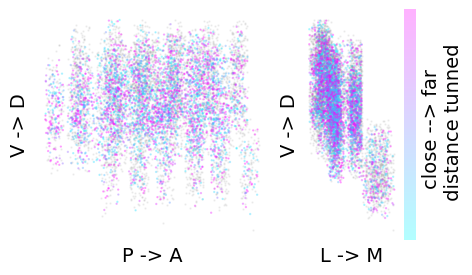

In [83]:
reload(anat_dtg)
f, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[2, 1])
anat_dtg.plot_anatomical_distance_tuning(anat_df, f=f, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/anatomical_distance_tuning.pdf")

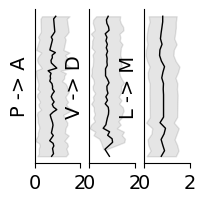

In [89]:
reload(anat_dtg)
f, axes = plt.subplots(1, 3, figsize=(2, 2), sharex=True)
anat_dtg.plot_axis_distance_tuning(anat_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/anatomical_distance_tuning_axes.pdf")